# Homework 8: Predicting Shortwave Radiation — Model Comparison & SHAP

**F&W ECOL 458 — Environmental Data Science**  
**[Ines Lopez-Silvero]:**
**Submission:** Upload your completed `.ipynb` to GitHub and submit the link to Canvas. **Before submitting, do Runtime > Restart and run all** to ensure all outputs are current.

---

### Overview

In this assignment you will predict incoming shortwave radiation at the Earth's surface from atmospheric and surface variables. You will train **all regression algorithms covered in the course**, compare their performance, and use **SHAP** to interpret the Random Forest and ANN models.

**Point breakdown:**

| Part | Topic | Points |
|---|---|---|
| 1 | Model comparison — all regressors | 55 |
| 2 | SHAP interpretation — Random Forest & ANN | 45 |
| **Total** | | **100** |

### The dataset

| Feature | Description | Unit |
|---|---|---|
| SZA | Solar Zenith Angle | degrees |
| AOD | Aerosol Optical Depth | unitless |
| COD | Cloud Optical Depth | unitless |
| CLD_FRAC | Cloud Fraction | 0-1 |
| UW | Water Column | cm |
| TO3 | Total Ozone | DU |
| Pressure | Surface Air Pressure | hPa |
| BSA | Black-Sky Albedo | 0-1 |
| WSA | White-Sky Albedo | 0-1 |

Targets: **SW_direct** (direct beam), **SW_diffuse** (scattered), and **SW = SW_direct + SW_diffuse** (total).

### Setup


In [3]:
# Run this cell first
!pip install xgboost shap -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')
print("Setup complete.")


Setup complete.


In [4]:
# ── Load data ──
# Replace with: df = pd.read_csv('SW.csv') if the file is available
np.random.seed(42)
n = 5000
SZA = np.random.uniform(0, 85, n)
AOD = np.random.exponential(0.15, n)
COD = np.random.exponential(5, n)
CLD_FRAC = np.random.uniform(0, 1, n)
UW = np.random.uniform(0.5, 5, n)
TO3 = np.random.uniform(250, 450, n)
Pressure = np.random.uniform(850, 1050, n)
BSA = np.random.uniform(0.05, 0.4, n)
WSA = np.random.uniform(0.05, 0.4, n)

cos_sza = np.cos(np.radians(SZA))
SW_direct = np.maximum(0, 1361 * cos_sza * np.exp(-AOD / np.clip(cos_sza, 0.05, 1))
                       * (1 - CLD_FRAC * 0.9) + np.random.normal(0, 15, n))
SW_diffuse = np.maximum(0, 200 * cos_sza * (0.3 + 0.5 * CLD_FRAC + 0.3 * AOD)
                        + np.random.normal(0, 10, n))

df = pd.DataFrame({
    'SZA': SZA, 'AOD': AOD, 'COD': COD, 'CLD_FRAC': CLD_FRAC,
    'UW': UW, 'TO3': TO3, 'Pressure': Pressure, 'BSA': BSA, 'WSA': WSA,
    'SW_direct': SW_direct, 'SW_diffuse': SW_diffuse
})
df['SW'] = df['SW_direct'] + df['SW_diffuse']

feature_cols = ['SZA', 'AOD', 'COD', 'CLD_FRAC', 'UW', 'TO3', 'Pressure', 'BSA', 'WSA']
print(f"Dataset: {df.shape[0]} samples, {len(feature_cols)} features, 3 targets")

Dataset: 5000 samples, 9 features, 3 targets


## Part 1: Model Comparison — All Regressors (55 points)


### 1.1 Prepare train/test split (5 pts)

1. Define `X` (9 features), `y_total` (SW), `y_direct` (SW_direct), and `y_diffuse` (SW_diffuse).
2. Split into 75% train / 25% test (`random_state=42`).
3. Create **scaled** versions using `StandardScaler` for algorithms that require it.


In [5]:
X=df[feature_cols]
# Define y as a DataFrame containing all target columns
targets_cols = ['SW_direct','SW_diffuse','SW']
y_all_targets = df[targets_cols]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test=train_test_split(X,y_all_targets,test_size=0.25,random_state=42)

scaler=StandardScaler()


### 1.2 Train all regressors (20 pts)

Train the following **7 regressors** on `SW` (total shortwave):

| Algorithm | Use scaled data? | Key parameters |
|---|---|---|
| Linear Regression | Yes | default |
| KNN (k=10) | Yes | `n_neighbors=10` |
| SVR (RBF) | Yes | `C=100` |
| Decision Tree | No | `max_depth=10` |
| Random Forest | No | `n_estimators=200` |
| XGBoost | No | `n_estimators=500, max_depth=6, learning_rate=0.1` |
| ANN (MLP) | Yes | `MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=500, early_stopping=True)` |

For each, record **test R$^2$**, **test RMSE**, and **training time**.

Print a summary table and create:
1. A **bar chart** comparing test R$^2$ across all 7 models.
2. A **2x4 grid of 1:1 scatter plots** (observed vs. predicted) with R$^2$ in each title. Leave the 8th subplot empty.

**Answer:** Which model achieves the best test R$^2$? Which is fastest? Why do tree-based ensembles outperform linear regression on this dataset?


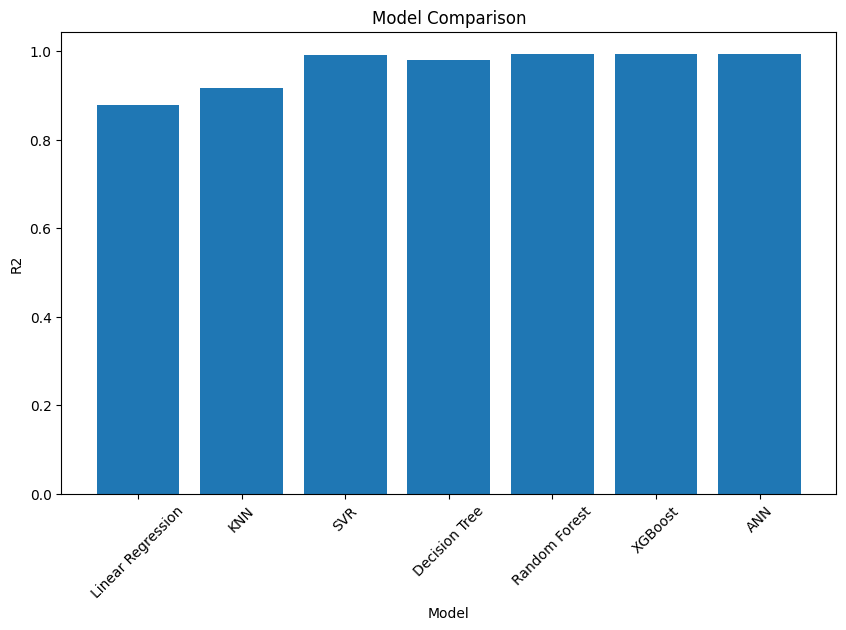

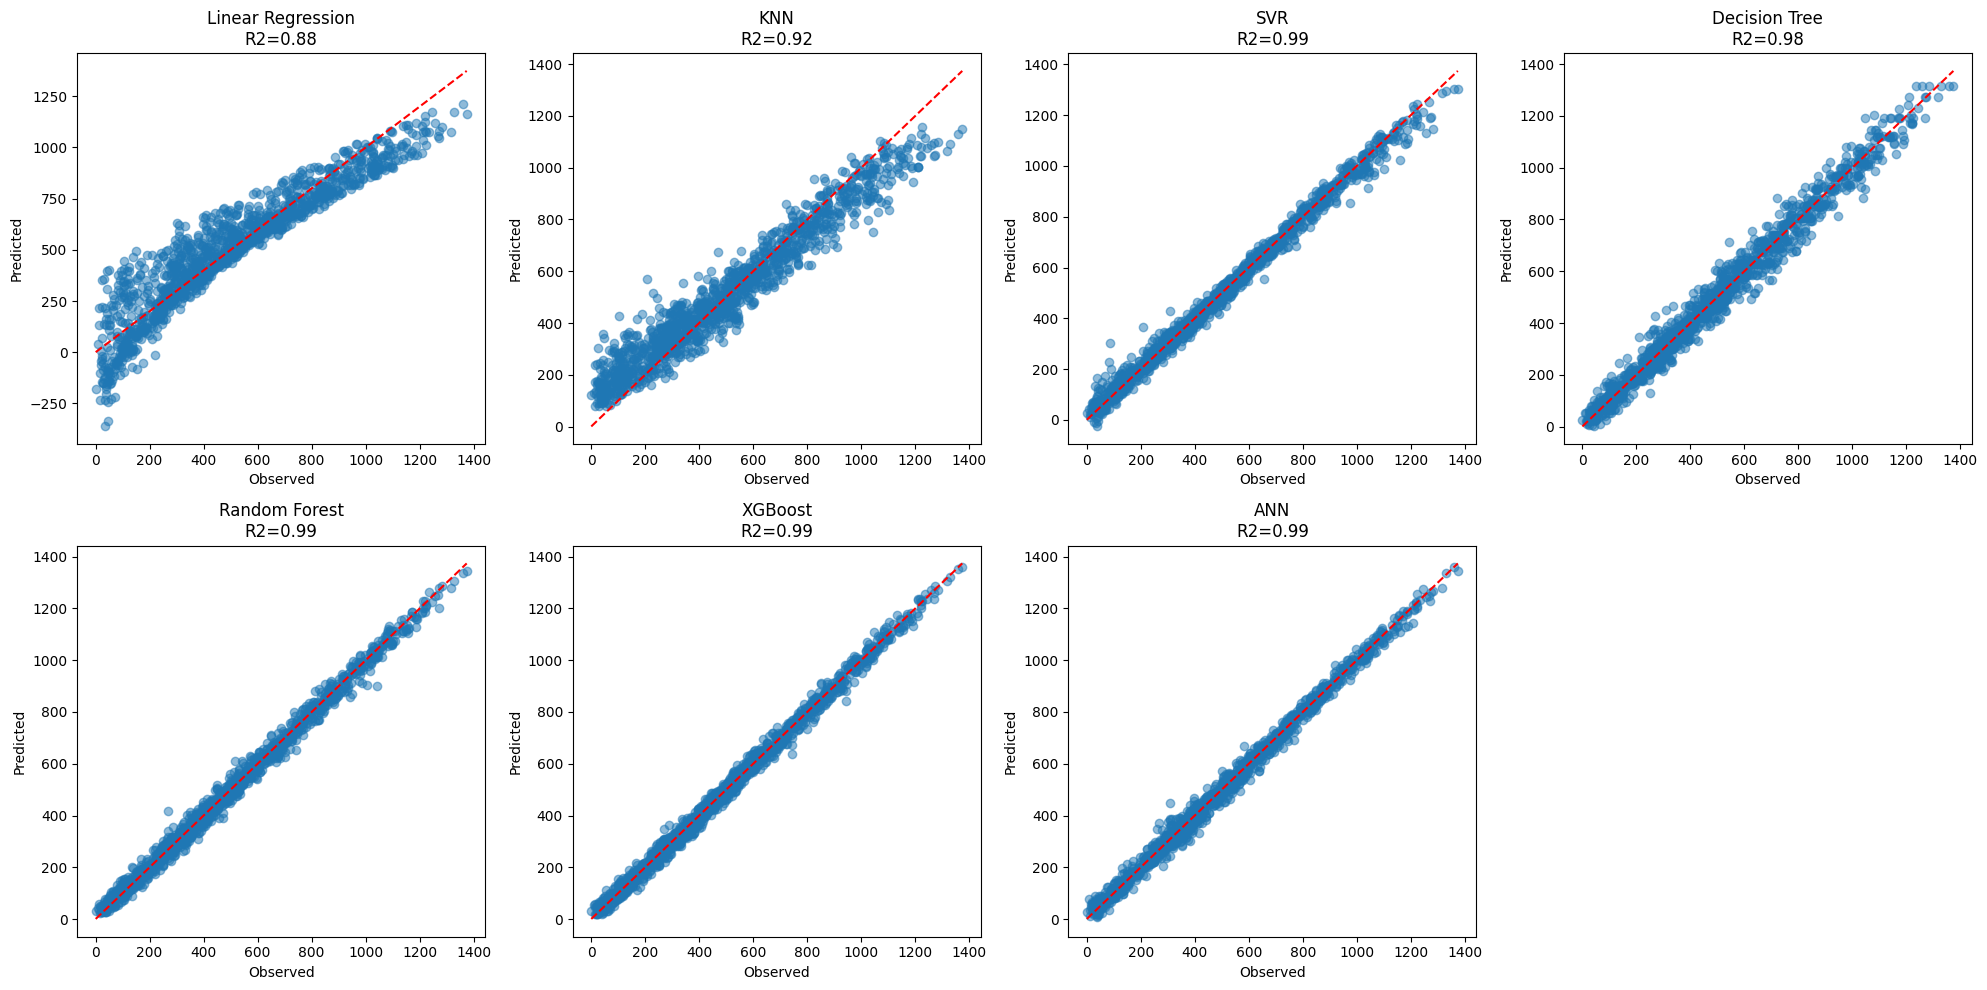

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

# YOUR CODE HERE
scaler=StandardScaler()
X_train_sc=scaler.fit_transform(X_train)
X_test_sc=scaler.transform(X_test)

classifiers= {
    "Linear Regression": {"model": LinearRegression(), "use_scaler": True},
    "KNN": {"model": KNeighborsRegressor(n_neighbors=10), "use_scaler": True},
    "SVR": {"model": SVR(C=100), "use_scaler": True},
    "Decision Tree": {"model": DecisionTreeRegressor(max_depth=10), "use_scaler": False},
    "Random Forest": {"model": RandomForestRegressor(n_estimators=200), "use_scaler": False},
    "XGBoost": {"model": XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.1), "use_scaler": False},
    "ANN": {"model": MLPRegressor(hidden_layer_sizes=(128,64), max_iter=500, early_stopping=True), "use_scaler": True}
}

results=[]
for name, classifier_info in classifiers.items():
  model = classifier_info["model"]
  use_scaler = classifier_info["use_scaler"]

  xt=X_train_sc if use_scaler else X_train
  xv=X_test_sc if use_scaler else X_test

  start_time=time.time()
  model.fit(xt,y_train['SW'])
  elapsed=time.time()-start_time
  y_pred=model.predict(xv)
  r2=r2_score(y_test['SW'],y_pred)
  rmse=root_mean_squared_error(y_test['SW'],y_pred)
  results.append({"Model":name,"R2":r2,"RMSE":rmse,"Time":elapsed})

results_df=pd.DataFrame(results)

plt.figure(figsize=(10,6))
plt.bar(results_df["Model"],results_df["R2"])
plt.xlabel("Model")
plt.ylabel("R2")
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.show()

fig,axes=plt.subplots(2,4,figsize=(20,10))
axes=axes.flatten()
for i,name in enumerate(classifiers.keys()):
  ax=axes[i]
  # To get the y_pred for each model, we need to re-run prediction
  # This is a bit inefficient but ensures correct R2 for each subplot
  model = classifiers[name]["model"]
  use_scaler = classifiers[name]["use_scaler"]
  xv=X_test_sc if use_scaler else X_test
  y_pred_for_plot = model.predict(xv)

  ax.scatter(y_test['SW'],y_pred_for_plot,alpha=0.5)
  ax.plot([y_test['SW'].min(),y_test['SW'].max()], [y_test['SW'].min(),y_test['SW'].max()],'r--')
  ax.set_xlabel("Observed")
  ax.set_ylabel("Predicted")
  # Fetch the R2 for the current model from results_df
  current_r2 = results_df[results_df["Model"] == name]["R2"].iloc[0]
  ax.set_title(f"{name}\nR2={current_r2:.2f}")

# Hide the 8th empty subplot if there are only 7 models
if len(classifiers) < len(axes):
    axes[len(classifiers)].axis('off')

plt.tight_layout()
plt.show()

*Your written answer here:* There is a three way tie beteewn Random Forest, XGBoost, and ANN for best R^2. The model that is the fastest... Tree based ensembles outperform linear regression on this datatset because they can handle non-linearity, it intersects variables, and can ignore noise.  



### 1.3 Predict all three radiation components (15 pts)

Using **Random Forest** and **ANN (MLP)** separately:

1. Train each on **SW_direct**, **SW_diffuse**, and **SW_total** (3 targets x 2 models = 6 models total).
2. Create a **2x3 grid of 1:1 plots**: top row = Random Forest, bottom row = ANN. Columns = SW_direct, SW_diffuse, SW_total. Show R$^2$ and RMSE in each title.

**Answer:**
1. Which radiation component is hardest to predict? Why might this be the case physically?
2. Does Random Forest or ANN perform better overall? Is the difference consistent across all three components?


Start ANN-SW
End ANN-SW


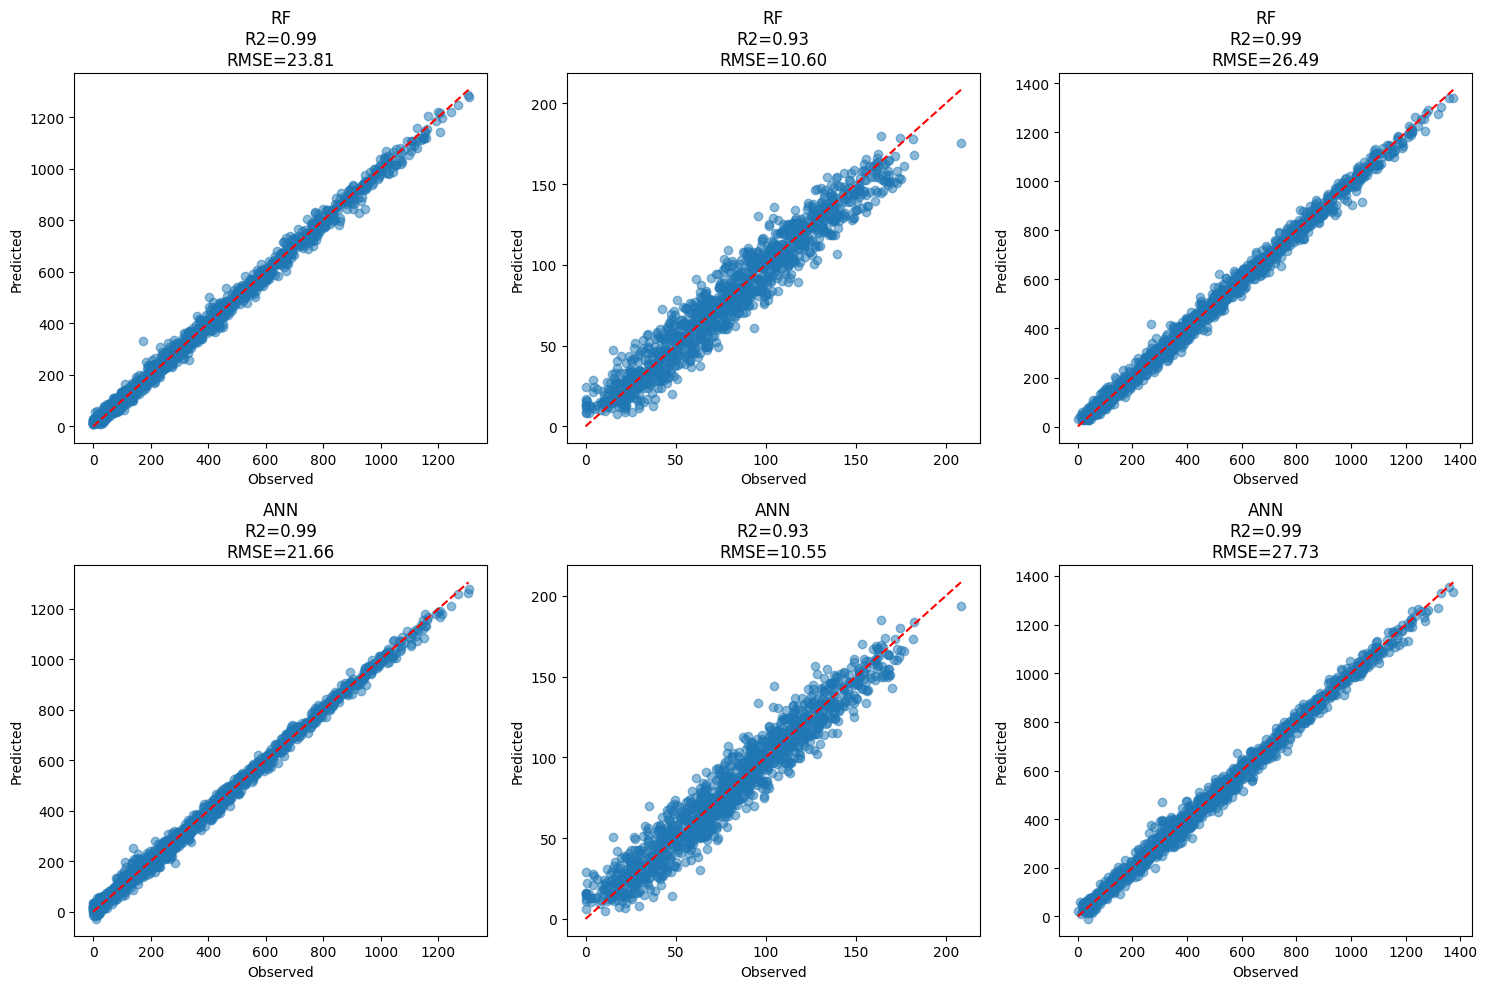

In [15]:
# YOUR CODE HERE

import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

targets=['SW_direct','SW_diffuse','SW']
models={'RF':RandomForestRegressor(n_estimators=200, random_state=42),'ANN':MLPRegressor(hidden_layer_sizes=(128,64),max_iter=500, early_stopping=True)}

fig,axes=plt.subplots(2,3,figsize=(15,10))

for row, (m_name, _) in enumerate(models.items()):
  for col, target in enumerate(targets):
    if m_name=="RF":
       model=RandomForestRegressor(n_estimators=200, random_state=42)
    else:
        model=MLPRegressor(hidden_layer_sizes=(128,64),max_iter=500, early_stopping=True)

    y_train_sub=y_train[target].values.ravel()
    y_test_sub=y_test[target].values.ravel()


    X_train_in = X_train_sc if m_name == "ANN" else X_train
    X_test_in = X_test_sc if m_name == "ANN" else X_test

    model.fit(X_train_in, y_train_sub)
    y_pred = model.predict(X_test_in)
    r2 = r2_score(y_test_sub, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_sub, y_pred))

    ax=axes[row,col]
    ax.scatter(y_test_sub, y_pred, alpha=0.5)
    line_min=min(y_test_sub.min(), y_pred.min())
    line_max=max(y_test_sub.max(), y_pred.max())
    ax.plot([y_test_sub.min(), y_test_sub.max()], [y_test_sub.min(), y_test_sub.max()], 'r--')
    ax.set_xlabel("Observed")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{m_name}\nR2={r2:.2f}\nRMSE={rmse:.2f}")
print(f"Start {m_name}-{target}")
model.fit(X_train_in, y_train_sub)
print(f"End {m_name}-{target}")
plt.tight_layout()
plt.show()


*Your written answer here:* The radiation component that is the hardest to predict is the middle column because it has the lowest R^2 values and has a lot of noise. This is probably because it is effected by a lot of different atmospheric conditions. Overall ANN performs a little better even though they both share the same R^2 the RMSE is slightly different.



### 1.4 Feature importance (15 pts)

1. Extract **Gini feature importance** from the Random Forest model (SW_total).
2. Compute **permutation importance** for the same model (`n_repeats=10` on the test set).
3. Plot both as side-by-side horizontal bar charts.


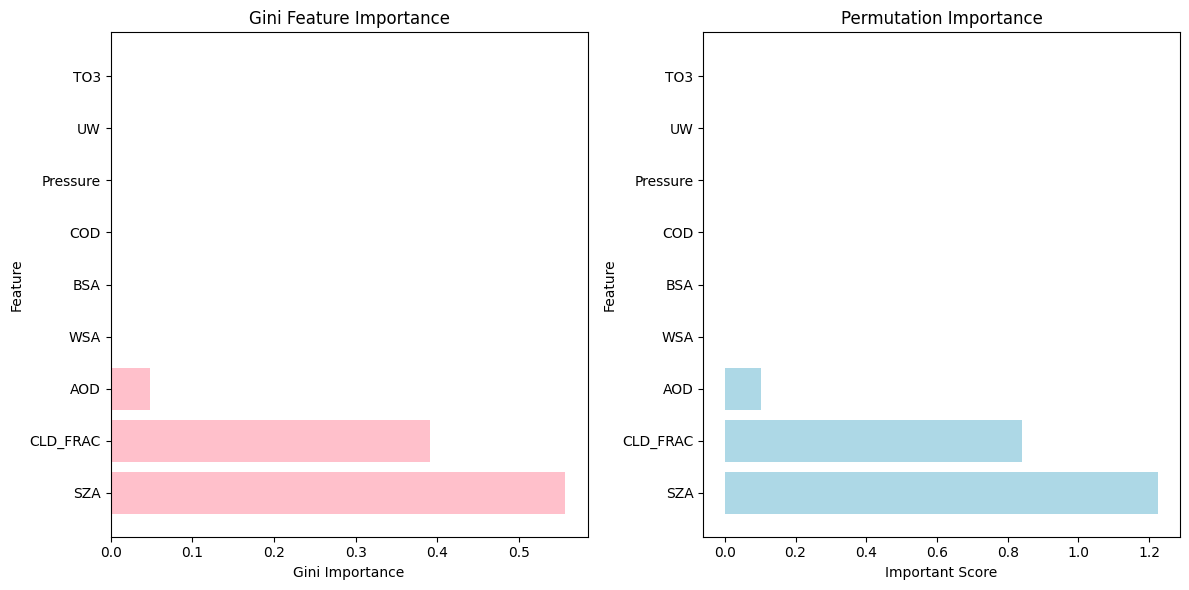

In [8]:
# YOUR CODE HERE
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
from sklearn.inspection import permutation_importance

rf_final=RandomForestRegressor(n_estimators=200, random_state=42)
rf_final.fit(X_train, y_train['SW'])

gini_importances=rf_final.feature_importances_
perm_result=permutation_importance(rf_final,X_test,y_test['SW'],n_repeats=10, random_state=42)
perm_importances=perm_result.importances_mean
feature_names=X.columns if hasattr(X_train, 'columns') else [f'Feature {i}' for i in range(X_train.shape[1])]
importance_df=pd.DataFrame({'Feature':feature_names,'Gini':gini_importances,'Permutation':perm_importances})
importance_df=importance_df.sort_values(by='Permutation',ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.barh(importance_df['Feature'], importance_df['Gini'], color='pink')
ax1.set_xlabel('Gini Importance')
ax1.set_ylabel('Feature')
ax1.set_title('Gini Feature Importance')

ax2.barh(importance_df['Feature'], importance_df['Permutation'], color='lightblue')
ax2.set_xlabel('Important Score')
ax2.set_ylabel('Feature')
ax2.set_title('Permutation Importance')

plt.tight_layout()
plt.show()




## Part 2: SHAP Interpretation — Random Forest & ANN (45 points)

Use `shap.TreeExplainer` for Random Forest and `shap.KernelExplainer` for ANN.

For `KernelExplainer`, use a subsample to keep computation manageable:
```python
background = shap.sample(X_train_sc, 100)
explainer_ann = shap.KernelExplainer(mlp_model.predict, background)
shap_values_ann = explainer_ann.shap_values(X_test_sc[:200])
```


### 2.1 SHAP for Random Forest (20 pts)

1. Compute SHAP values for your Random Forest (SW_total) on the test set.
2. Produce a **SHAP beeswarm (summary) plot**.
3. Produce a **SHAP bar plot** (mean |SHAP value| per feature).
4. Produce **SHAP dependence plots** for **SZA**, **CLD_FRAC**, and **AOD**.

**Answer:**
1. In the beeswarm plot, does high SZA increase or decrease SW? Is this physically correct?
2. What is the direction of effect for CLD_FRAC? Explain the physics in one sentence.
3. In the SZA dependence plot, is the relationship linear or nonlinear? Describe its shape and explain why.
4. In the AOD dependence plot, what does the interaction color reveal?


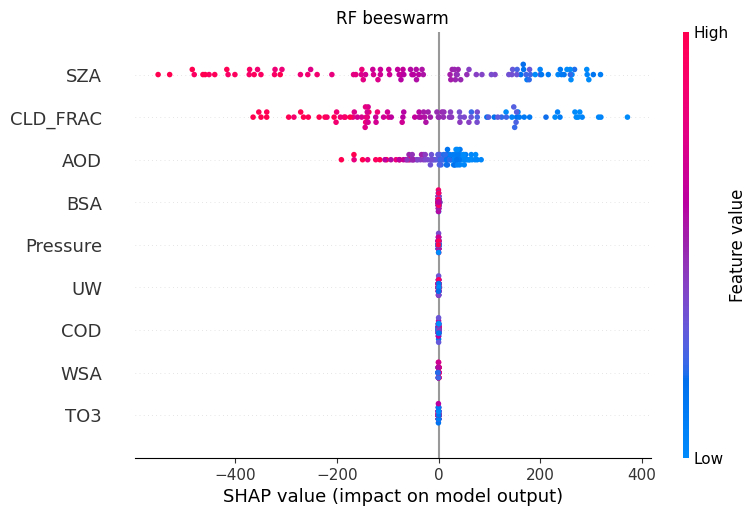

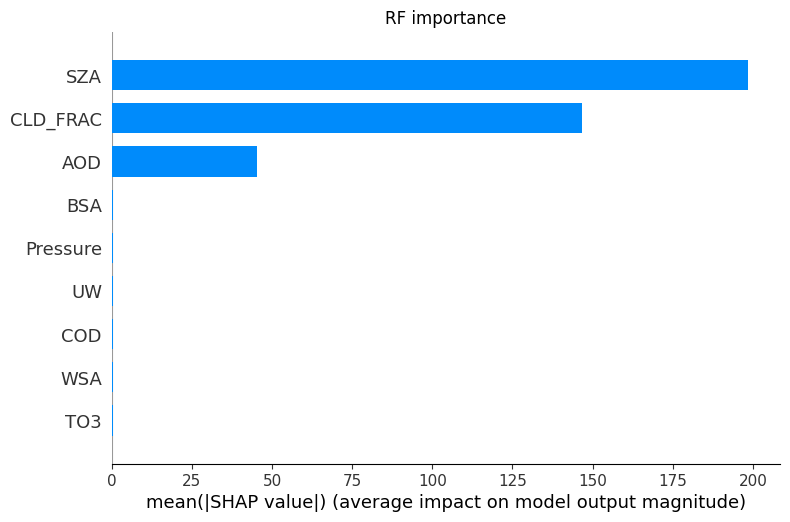

<Figure size 640x480 with 0 Axes>

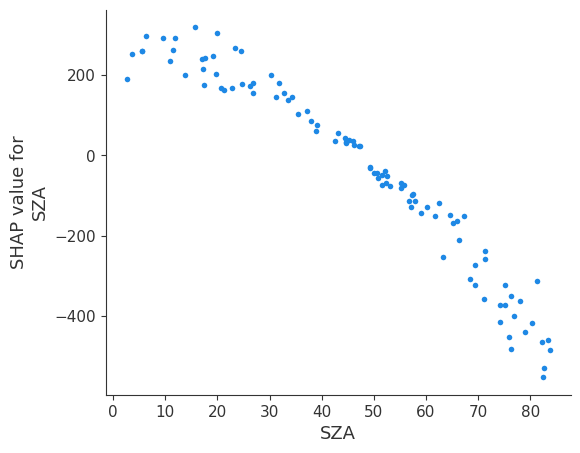

<Figure size 640x480 with 0 Axes>

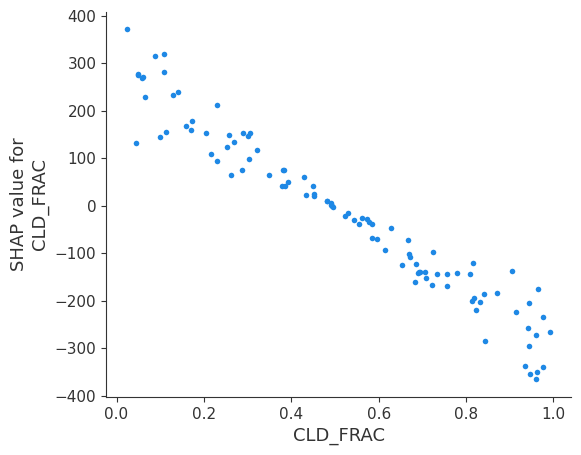

<Figure size 640x480 with 0 Axes>

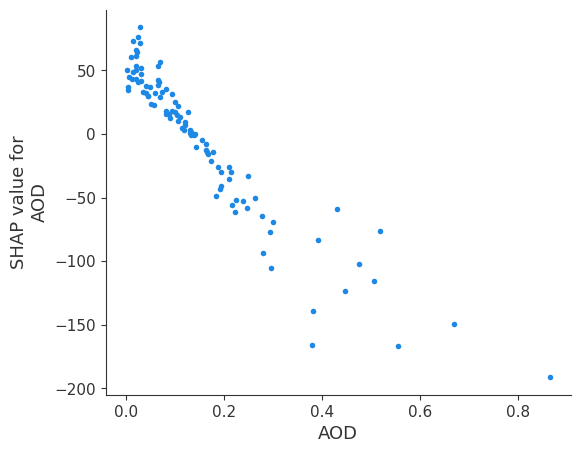

In [9]:
import shap
import matplotlib.pyplot as plt


explainer_rf=shap.TreeExplainer(rf_final)
X_test_small= X_test.sample(100, random_state=42) if hasattr(X_test, 'sample') else X_test[:100]
shap_values_rf=explainer_rf.shap_values(X_test_small)

plt.figure()
shap.summary_plot(shap_values_rf,X_test_small,plot_type="dot",show=False)
plt.title("RF beeswarm")

plt.figure()
shap.summary_plot(shap_values_rf,X_test_small,plot_type="bar",show=False)
plt.title("RF importance")

for feature in['SZA','CLD_FRAC','AOD']:
  plt.figure()
  shap.dependence_plot(feature,shap_values_rf,X_test_small,interaction_index=None)


*Your written answers here:* The high SZA results in a negative SHAP value so the SW radiation decreases. This is physically correct. The direction of CLD_FRAC is increasing which has a negative effect on SW radiation. Higher cloud fraction increases the atmospheric reflectivity. In the SZA dependence plot the relationship is nonlinear. In the AOD dependence plot the interaction color reveals how the impact of aerosols changes depending on a second variable.  



### 2.2 SHAP for ANN — Comparison with Random Forest (25 pts)

1. Compute SHAP values for your ANN (SW_total) using `KernelExplainer` on 200 test samples.
2. Display the **RF beeswarm** and **ANN beeswarm** side by side.
3. Display the **RF bar plot** and **ANN bar plot** side by side.

**Answer:**
1. Do RF and ANN agree on the top 3 most important features? List them for each model.
2. Are the directions of effect the same for both models?
3. If there are any differences, explain why a tree-based model and a neural network might learn slightly different representations of the same physics.
4. Based on both accuracy (Part 1) and SHAP (this section), which model would you trust more for this task and why?


NameError: name 'shap_values_ann' is not defined

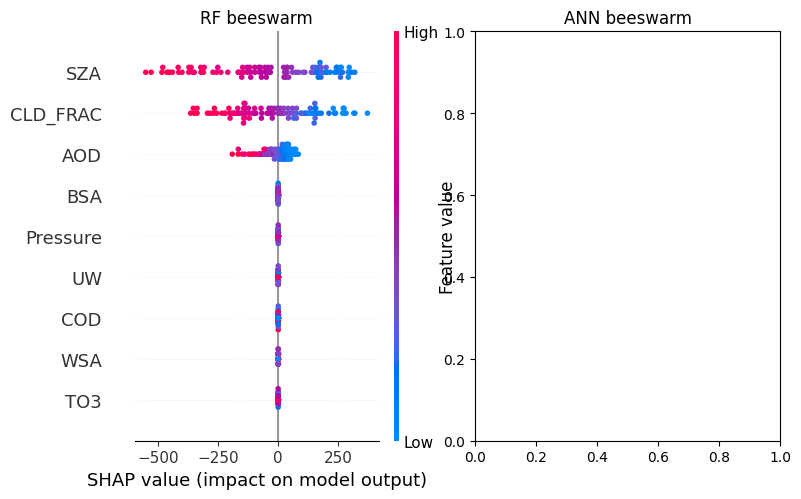

In [11]:
# YOUR CODE HERE

import shap
import matplotlib.pyplot as plt

num_samples=200
plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
plt.title("RF beeswarm")
shap.summary_plot(shap_values_rf, X_test_small, show=False)
plt.subplot(1,2,2)
plt.title("ANN beeswarm")

shap.summary_plot(shap_values_ann, X_test_sc[:num_samples], show=False)

plt.tight_layout()
plt.show()

plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
plt.title("RF importance")

shap.summary_plot(shap_values_rf, X_test_small, plot_type="bar", show=False)
plt.subplot(1,2,2)
plt.title("ANN importance")
shap.summary_plot(shap_values_ann, X_test_sc[:num_samples], plot_type="bar", show=False)





plt.tight_layout()
plt.show()

*Your written answers here:* RF and ANN agree with the top 3 important features. For RF the ranking goes:SZA,CLD_FRAC, and AOD. For ANN the ranking going: Feature 0(SZA), feature 3(CLD_FRAC), and feature 1(AOD). The directions of effect are the same direction for both models. For tree-based models it can capture non-linear points in the weather data while the neural network uses continous functions and captures muilti-dimensional interactions. The RF is the best model for this task because it received an R^2 or 0.99, and the SHAP values for RF are very stable as they map the features very clearly.

